C:\Users\HP\AppData\Local\Temp\ipykernel_28288\3638562105.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


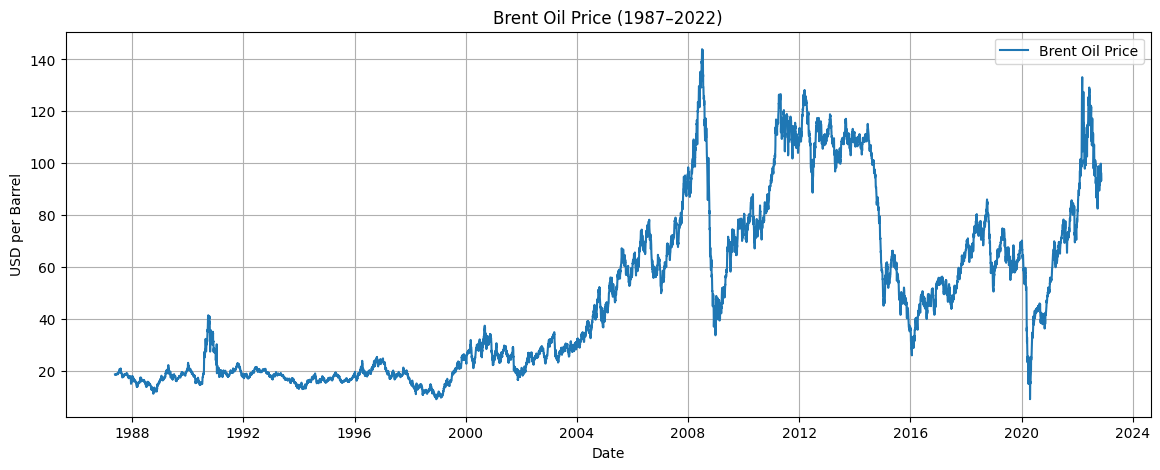

ADF Statistic: -1.9938560113924675
p-value: 0.28927350489340287
Critical Values: {'1%': -3.4310783342658615, '5%': -2.861861876398633, '10%': -2.566941329781918}


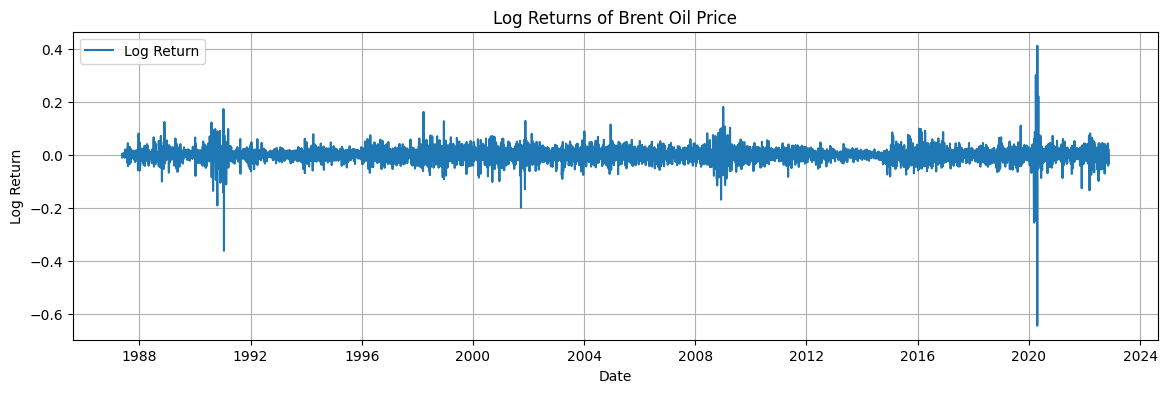

<Figure size 640x480 with 0 Axes>

In [ ]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import numpy as np

# 2. Load dataset
df = pd.read_csv("../data/brentoilprices.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

# 3. Plot price time series
plt.figure(figsize=(14, 5))
plt.plot(df['Price'], label='Brent Oil Price')
plt.title("Brent Oil Price (1987–2022)")
plt.xlabel("Date")
plt.ylabel("USD per Barrel")
plt.legend()
plt.grid()
plt.show()

# 4. Check stationarity with ADF test
result = adfuller(df['Price'].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

# 5. Compute log returns
df['log_return'] = np.log(df['Price'] / df['Price'].shift(1))

# 6. Plot log returns
plt.figure(figsize=(14, 4))
plt.plot(df['log_return'], label='Log Return')
plt.title("Log Returns of Brent Oil Price")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid()
plt.legend()
plt.show()
plt.savefig("../Visualizations/fig_brent_price.png", bbox_inches='tight')
plt.savefig("../Visualizations/fig_log_returns.png", bbox_inches='tight')


### Summary:

- The time series shows several noticeable shocks and long-term volatility changes.
- The Augmented Dickey-Fuller (ADF) test suggests the price series is **non-stationary** (p-value > 0.05).
- Log returns appear more stationary and will likely be used for Bayesian modeling.
